In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#K-means 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score




In [32]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [33]:
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [34]:
gender_id = {
    'Male': 0,
    'Female':1
}
df['GenderId'] = df['Gender'].map(gender_id)

In [35]:
df.columns


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'GenderId'],
      dtype='str')

In [36]:
X = df[['Age', 'Annual Income (k$)','Spending Score (1-100)','GenderId']]

In [37]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

In [65]:
error_rate = []
k_range = range(1,21)
for i in k_range:
    kmeans = KMeans(n_clusters=i)
    kmeans.fit_predict(X_scale)
    error_rate.append(kmeans.inertia_)

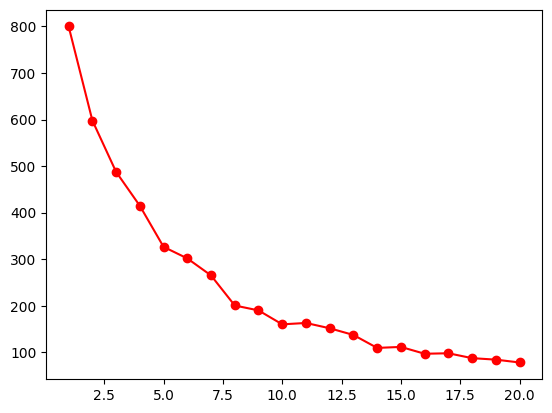

In [66]:
plt.plot(k_range ,error_rate , c='red', marker='o')

In [70]:
model = KMeans(n_clusters=5)
clusters = model.fit_predict(X_scale)

In [71]:
show_labels = model.labels_

In [75]:
#accuracy for clustering
#as accuracy does not affect model itself.
ss= silhouette_score(X_scale, show_labels)
print(ss)

0.3010283600403604


In [74]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x='Age', y='spending Score(1-100)',hue='clusters',palette="viridis")

ValueError: Could not interpret value `spending Score(1-100)` for `y`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>